In [1]:
import pandas as pd

In [2]:
ipl=pd.read_csv('ipl-matches.csv')

In [3]:
ipl.loc[945]

ID                                                            335986
City                                                         Kolkata
Date                                                      2008-04-20
Season                                                       2007/08
MatchNumber                                                        4
Team1                                          Kolkata Knight Riders
Team2                                                Deccan Chargers
Venue                                                   Eden Gardens
TossWinner                                           Deccan Chargers
TossDecision                                                     bat
SuperOver                                                          N
WinningTeam                                    Kolkata Knight Riders
WonBy                                                        Wickets
Margin                                                           5.0
method                            

In [4]:
ipl['ID']=ipl['ID'].astype('int32')
ipl['Season']=ipl['Season'].astype('category')
ipl['Team1']=ipl['Team1'].astype('category')
ipl['Team2']=ipl['Team2'].astype('category')
 #Converting datatypes save memory you can see by using info() method

In [5]:
ipl[ipl['MatchNumber']=='Final'][['Season','WinningTeam']] #Finding Winning team of every season in final matches

,Season,WinningTeam
0,2022,Gujarat Titans
74,2021,Chennai Super Kings
134,2020/21,Mumbai Indians
194,2019,Mumbai Indians
254,2018,Chennai Super Kings
314,2017,Mumbai Indians
373,2016,Sunrisers Hyderabad
433,2015,Mumbai Indians
492,2014,Kolkata Knight Riders
552,2013,Mumbai Indians


In [6]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   ID               950 non-null    int32   
 1   City             899 non-null    object  
 2   Date             950 non-null    object  
 3   Season           950 non-null    category
 4   MatchNumber      950 non-null    object  
 5   Team1            950 non-null    category
 6   Team2            950 non-null    category
 7   Venue            950 non-null    object  
 8   TossWinner       950 non-null    object  
 9   TossDecision     950 non-null    object  
 10  SuperOver        946 non-null    object  
 11  WinningTeam      946 non-null    object  
 12  WonBy            950 non-null    object  
 13  Margin           932 non-null    float64 
 14  method           19 non-null     object  
 15  Player_of_Match  946 non-null    object  
 16  Team1Players     950 non-null    object  
 1

In [7]:
#Finding Winning team of every season in final matches
mask=ipl['MatchNumber']=='Final'
new_data=ipl[mask]
new_data[['Season','WinningTeam']]


,Season,WinningTeam
0,2022,Gujarat Titans
74,2021,Chennai Super Kings
134,2020/21,Mumbai Indians
194,2019,Mumbai Indians
254,2018,Chennai Super Kings
314,2017,Mumbai Indians
373,2016,Sunrisers Hyderabad
433,2015,Mumbai Indians
492,2014,Kolkata Knight Riders
552,2013,Mumbai Indians


In [8]:
ipl['SuperOver'].value_counts()['Y']

np.int64(14)

In [9]:
(ipl['SuperOver']=='Y').sum()

np.int64(14)

In [10]:
ipl[ipl['SuperOver']=='Y'].shape[0]

14

In [11]:
#How many matches won by CSK on kolkata
ipl[(ipl['City']=='Kolkata') & (ipl['WinningTeam']=='Chennai Super Kings')].shape[0]

5

In [12]:
#Toss Winner is Match Winner percentage
toss_winner=ipl[ipl['TossWinner']==ipl['WinningTeam']].shape[0]
(toss_winner/len(ipl))*100

51.473684210526315

In [13]:
pd.concat([ipl['Team1'],ipl['Team2']]).value_counts()


Mumbai Indians                 231
Royal Challengers Bangalore    226
Kolkata Knight Riders          223
Chennai Super Kings            208
Rajasthan Royals               192
Kings XI Punjab                190
Delhi Daredevils               161
Sunrisers Hyderabad            152
Deccan Chargers                 75
Delhi Capitals                  63
Pune Warriors                   46
Gujarat Lions                   30
Punjab Kings                    28
Gujarat Titans                  16
Rising Pune Supergiant          16
Lucknow Super Giants            15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

In [14]:
# Writing a function that returns the head-to-head track record between any two IPL teams.
# showing how many matches each team has won against the other.
def track(team1,team2):
    track_recor=ipl[((ipl['Team1']==team1) & (ipl['Team2']==team2)) | ((ipl['Team1']==team2) & (ipl['Team2']==team1))]
    return track_recor['WinningTeam'].value_counts()
track('Royal Challengers Bangalore','Mumbai Indians')

WinningTeam
Mumbai Indians                 17
Royal Challengers Bangalore    13
Name: count, dtype: int64

In [15]:
#Addign new column
ipl['new']='y'
ipl.loc[:356,'new']='N'

In [16]:
ipl

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,new
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,N
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,...,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon,N
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,...,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough,N
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,...,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma,N
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,...,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,...,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan,y
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,...,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper,y
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,...,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar,y
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,...,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri,y


In [17]:
# Finding which player has won most man of the match in finals and semifinals
ipl.head(2)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,new
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,N
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,...,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon,N


In [18]:
# Finding man of the match in final or qualifiers
ipl[~ipl['MatchNumber'].str.isdigit()]['Player_of_Match'].value_counts()

Player_of_Match
F du Plessis         3
SK Raina             3
KA Pollard           3
JJ Bumrah            2
AB de Villiers       2
MK Pandey            2
M Vijay              2
A Kumble             2
YK Pathan            2
SR Watson            2
HH Pandya            1
RM Patidar           1
JC Buttler           1
RR Pant              1
KS Williamson        1
MP Stoinis           1
TA Boult             1
SP Narine            1
RD Gaikwad           1
VR Iyer              1
DA Miller            1
Washington Sundar    1
NM Coulter-Nile      1
KV Sharma            1
BCJ Cutting          1
KH Pandya            1
SA Yadav             1
Rashid Khan          1
AD Russell           1
RG Sharma            1
A Nehra              1
DA Warner            1
MC Henriques         1
Harbhajan Singh      1
BJ Hodge             1
UT Yadav             1
V Sehwag             1
MS Bisla             1
MEK Hussey           1
CH Gayle             1
MS Dhoni             1
MM Patel             1
DE Bollinger      

<Axes: ylabel='count'>

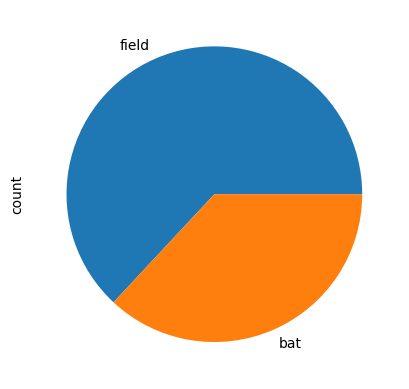

In [19]:
#toss decision plot
ipl['TossDecision'].value_counts().plot(kind='pie')

In [20]:
#How many matches each team played
a=ipl['Team1'].value_counts()
b=ipl['Team2'].value_counts()
(a+b).sort_values(ascending=False)

Mumbai Indians                 231
Royal Challengers Bangalore    226
Kolkata Knight Riders          223
Chennai Super Kings            208
Rajasthan Royals               192
Kings XI Punjab                190
Delhi Daredevils               161
Sunrisers Hyderabad            152
Deccan Chargers                 75
Delhi Capitals                  63
Pune Warriors                   46
Gujarat Lions                   30
Punjab Kings                    28
Gujarat Titans                  16
Rising Pune Supergiant          16
Lucknow Super Giants            15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

In [21]:
ipl['WinningTeam'].sort_values(na_position='first')


205                    NaN
437                    NaN
464                    NaN
708                    NaN
712    Chennai Super Kings
              ...         
272    Sunrisers Hyderabad
49     Sunrisers Hyderabad
520    Sunrisers Hyderabad
143    Sunrisers Hyderabad
291    Sunrisers Hyderabad
Name: WinningTeam, Length: 950, dtype: object

In [22]:
ipl.sort_values(by='WinningTeam',inplace=True)

In [23]:
ipl['Season'].unique()

['2011', '2021', '2009', '2014', '2020/21', ..., '2015', '2007/08', '2012', '2016', '2017']
Length: 15
Categories (15, object): ['2007/08', '2009', '2009/10', '2011', ..., '2019', '2020/21', '2021', '2022']

In [24]:
len(ipl['Season'].unique())
#nunique(series+dataframe)->does not count nan-> dropna parameter
ipl['Season'].nunique()

15

In [25]:
#isnull(series+datafram)
ipl.isnull().sum()

ID                   0
City                51
Date                 0
Season               0
MatchNumber          0
Team1                0
Team2                0
Venue                0
TossWinner           0
TossDecision         0
SuperOver            4
WinningTeam          4
WonBy                0
Margin              18
method             931
Player_of_Match      4
Team1Players         0
Team2Players         0
Umpire1              0
Umpire2              0
new                  0
dtype: int64

In [26]:
ipl['method'][ipl['method'].isnull()]

712    NaN
95     NaN
840    NaN
526    NaN
176    NaN
      ... 
291    NaN
205    NaN
437    NaN
464    NaN
708    NaN
Name: method, Length: 931, dtype: object

In [27]:
#notnull(series+dataframe)
ipl['method'][ipl['method'].notnull()]

860    D/L
908    D/L
282    D/L
889    D/L
910    D/L
296    D/L
757    D/L
886    D/L
728    D/L
389    D/L
316    D/L
308    D/L
411    D/L
384    D/L
441    D/L
383    D/L
717    D/L
472    D/L
520    D/L
Name: method, dtype: object

In [28]:
#hasnans[series] :  if missing value is present->yes else no
ipl['City'].hasnans


True

In [29]:
ipl.dropna(how='any')

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,new
860,392214,Centurion,2009-05-07,2009,34,Chennai Super Kings,Kings XI Punjab,SuperSport Park,Chennai Super Kings,bat,...,Chennai Super Kings,Runs,12.0,D/L,ML Hayden,"['S Badrinath', 'ML Hayden', 'SK Raina', 'MS D...","['S Sohal', 'SM Katich', 'K Goel', 'Yuvraj Sin...",DJ Harper,TH Wijewardene,y
908,336025,Kolkata,2008-05-18,2007/08,41,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Kolkata Knight Riders,bat,...,Chennai Super Kings,Runs,3.0,D/L,M Ntini,"['Salman Butt', 'Mohammad Hafeez', 'SC Ganguly...","['PA Patel', 'SP Fleming', 'S Vidyut', 'SK Rai...",Asad Rauf,K Hariharan,y
282,1136592,Delhi,2018-05-02,2018,32,Delhi Daredevils,Rajasthan Royals,Arun Jaitley Stadium,Rajasthan Royals,field,...,Delhi Daredevils,Runs,4.0,D/L,RR Pant,"['PP Shaw', 'C Munro', 'SS Iyer', 'RR Pant', '...","['DJM Short', 'JC Buttler', 'SV Samson', 'BA S...",CK Nandan,VK Sharma,N
889,392183,Cape Town,2009-04-19,2009,3,Delhi Daredevils,Kings XI Punjab,Newlands,Delhi Daredevils,field,...,Delhi Daredevils,Wickets,10.0,D/L,DL Vettori,"['G Gambhir', 'V Sehwag', 'TM Dilshan', 'AB de...","['RS Bopara', 'K Goel', 'Yuvraj Singh', 'KC Sa...",MR Benson,SD Ranade,y
910,336022,Delhi,2008-05-17,2007/08,40,Delhi Daredevils,Kings XI Punjab,Feroz Shah Kotla,Delhi Daredevils,bat,...,Kings XI Punjab,Runs,6.0,D/L,DPMD Jayawardene,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'TM Dils...","['SE Marsh', 'JR Hopes', 'Yuvraj Singh', 'LA P...",AV Jayaprakash,RE Koertzen,y
296,1136578,Kolkata,2018-04-21,2018,18,Kolkata Knight Riders,Kings XI Punjab,Eden Gardens,Kings XI Punjab,field,...,Kings XI Punjab,Wickets,9.0,D/L,KL Rahul,"['CA Lynn', 'SP Narine', 'RV Uthappa', 'N Rana...","['KL Rahul', 'CH Gayle', 'MA Agarwal', 'KK Nai...",A Deshmukh,C Shamshuddin,N
757,501215,Kochi,2011-04-18,2011,18,Kochi Tuskers Kerala,Chennai Super Kings,Nehru Stadium,Kochi Tuskers Kerala,field,...,Kochi Tuskers Kerala,Wickets,7.0,D/L,BB McCullum,"['BB McCullum', 'DPMD Jayawardene', 'PA Patel'...","['MEK Hussey', 'M Vijay', 'SK Raina', 'S Badri...",K Hariharan,AL Hill,y
886,392186,Durban,2009-04-21,2009,6,Kings XI Punjab,Kolkata Knight Riders,Kingsmead,Kolkata Knight Riders,field,...,Kolkata Knight Riders,Runs,11.0,D/L,CH Gayle,"['RS Bopara', 'K Goel', 'IK Pathan', 'KC Sanga...","['BB McCullum', 'CH Gayle', 'BJ Hodge', 'SC Ga...",DJ Harper,SD Ranade,y
728,501245,Kolkata,2011-05-07,2011,48,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Chennai Super Kings,bat,...,Kolkata Knight Riders,Runs,10.0,D/L,Iqbal Abdulla,"['EJG Morgan', 'JH Kallis', 'G Gambhir', 'MK T...","['MEK Hussey', 'M Vijay', 'SK Raina', 'S Badri...",Asad Rauf,PR Reiffel,y
389,980989,Kolkata,2016-05-14,2016,45,Kolkata Knight Riders,Rising Pune Supergiants,Eden Gardens,Rising Pune Supergiants,bat,...,Kolkata Knight Riders,Wickets,8.0,D/L,YK Pathan,"['RV Uthappa', 'G Gambhir', 'MK Pandey', 'YK P...","['AM Rahane', 'UT Khawaja', 'GJ Bailey', 'SS T...",A Nand Kishore,BNJ Oxenford,y


In [30]:
ipl.dropna(how='all')#if all vales in a row is missing then it will remove it  

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,new
712,501261,Chennai,2011-05-18,2011,64,Chennai Super Kings,Kochi Tuskers Kerala,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,bat,...,Chennai Super Kings,Runs,11.0,NaN,WP Saha,"['MEK Hussey', 'M Vijay', 'SK Raina', 'S Badri...","['PA Patel', 'BB McCullum', 'Y Gnaneswara Rao'...",HDPK Dharmasena,RE Koertzen,y
95,1254098,Abu Dhabi,2021-09-26,2021,38,Kolkata Knight Riders,Chennai Super Kings,"Zayed Cricket Stadium, Abu Dhabi",Kolkata Knight Riders,bat,...,Chennai Super Kings,Wickets,2.0,NaN,RA Jadeja,"['Shubman Gill', 'VR Iyer', 'RA Tripathi', 'EJ...","['RD Gaikwad', 'F du Plessis', 'MM Ali', 'AT R...",CB Gaffaney,Tapan Sharma,N
840,392234,Durban,2009-05-20,2009,54,Chennai Super Kings,Kings XI Punjab,Kingsmead,Chennai Super Kings,bat,...,Chennai Super Kings,Runs,24.0,NaN,M Muralitharan,"['GJ Bailey', 'PA Patel', 'SK Raina', 'S Badri...","['S Sohal', 'SM Katich', 'LA Pomersbach', 'Yuv...",BG Jerling,SJA Taufel,y
526,733981,Delhi,2014-05-05,2014,26,Delhi Daredevils,Chennai Super Kings,Feroz Shah Kotla,Chennai Super Kings,field,...,Chennai Super Kings,Wickets,8.0,NaN,DR Smith,"['Q de Kock', 'M Vijay', 'KP Pietersen', 'KD K...","['DR Smith', 'BB McCullum', 'SK Raina', 'MS Dh...",RM Deshpande,BNJ Oxenford,y
176,1216513,NaN,2020-10-04,2020/21,18,Kings XI Punjab,Chennai Super Kings,Dubai International Cricket Stadium,Kings XI Punjab,bat,...,Chennai Super Kings,Wickets,10.0,NaN,SR Watson,"['KL Rahul', 'MA Agarwal', 'Mandeep Singh', 'N...","['SR Watson', 'F du Plessis', 'AT Rayudu', 'KM...",AY Dandekar,Nitin Menon,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,1136583,Mumbai,2018-04-24,2018,23,Sunrisers Hyderabad,Mumbai Indians,Wankhede Stadium,Mumbai Indians,field,...,Sunrisers Hyderabad,Runs,31.0,NaN,Rashid Khan,"['S Dhawan', 'KS Williamson', 'WP Saha', 'MK P...","['SA Yadav', 'E Lewis', 'Ishan Kishan', 'RG Sh...",C Shamshuddin,S Ravi,N
205,1178424,Bengaluru,2019-04-30,2019,49,Royal Challengers Bangalore,Rajasthan Royals,M.Chinnaswamy Stadium,Rajasthan Royals,field,...,NaN,NoResults,NaN,NaN,NaN,"['V Kohli', 'AB de Villiers', 'MP Stoinis', 'H...","['SV Samson', 'LS Livingstone', 'AM Rahane', '...",NJ Llong,UV Gandhe,N
437,829813,Bangalore,2015-05-17,2015,55,Royal Challengers Bangalore,Delhi Daredevils,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,...,NaN,NoResults,NaN,NaN,NaN,"['V Kohli', 'CH Gayle', 'AB de Villiers', 'Man...","['Q de Kock', 'SS Iyer', 'JP Duminy', 'Yuvraj ...",HDPK Dharmasena,K Srinivasan,y
464,829763,Bangalore,2015-04-29,2015,29,Royal Challengers Bangalore,Rajasthan Royals,M Chinnaswamy Stadium,Rajasthan Royals,field,...,NaN,NoResults,NaN,NaN,NaN,"['CH Gayle', 'V Kohli', 'AB de Villiers', 'Man...","['AM Rahane', 'SR Watson', 'SPD Smith', 'KK Na...",JD Cloete,PG Pathak,y


In [31]:
ipl.dropna(subset=['Season'])

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,new
712,501261,Chennai,2011-05-18,2011,64,Chennai Super Kings,Kochi Tuskers Kerala,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,bat,...,Chennai Super Kings,Runs,11.0,NaN,WP Saha,"['MEK Hussey', 'M Vijay', 'SK Raina', 'S Badri...","['PA Patel', 'BB McCullum', 'Y Gnaneswara Rao'...",HDPK Dharmasena,RE Koertzen,y
95,1254098,Abu Dhabi,2021-09-26,2021,38,Kolkata Knight Riders,Chennai Super Kings,"Zayed Cricket Stadium, Abu Dhabi",Kolkata Knight Riders,bat,...,Chennai Super Kings,Wickets,2.0,NaN,RA Jadeja,"['Shubman Gill', 'VR Iyer', 'RA Tripathi', 'EJ...","['RD Gaikwad', 'F du Plessis', 'MM Ali', 'AT R...",CB Gaffaney,Tapan Sharma,N
840,392234,Durban,2009-05-20,2009,54,Chennai Super Kings,Kings XI Punjab,Kingsmead,Chennai Super Kings,bat,...,Chennai Super Kings,Runs,24.0,NaN,M Muralitharan,"['GJ Bailey', 'PA Patel', 'SK Raina', 'S Badri...","['S Sohal', 'SM Katich', 'LA Pomersbach', 'Yuv...",BG Jerling,SJA Taufel,y
526,733981,Delhi,2014-05-05,2014,26,Delhi Daredevils,Chennai Super Kings,Feroz Shah Kotla,Chennai Super Kings,field,...,Chennai Super Kings,Wickets,8.0,NaN,DR Smith,"['Q de Kock', 'M Vijay', 'KP Pietersen', 'KD K...","['DR Smith', 'BB McCullum', 'SK Raina', 'MS Dh...",RM Deshpande,BNJ Oxenford,y
176,1216513,NaN,2020-10-04,2020/21,18,Kings XI Punjab,Chennai Super Kings,Dubai International Cricket Stadium,Kings XI Punjab,bat,...,Chennai Super Kings,Wickets,10.0,NaN,SR Watson,"['KL Rahul', 'MA Agarwal', 'Mandeep Singh', 'N...","['SR Watson', 'F du Plessis', 'AT Rayudu', 'KM...",AY Dandekar,Nitin Menon,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,1136583,Mumbai,2018-04-24,2018,23,Sunrisers Hyderabad,Mumbai Indians,Wankhede Stadium,Mumbai Indians,field,...,Sunrisers Hyderabad,Runs,31.0,NaN,Rashid Khan,"['S Dhawan', 'KS Williamson', 'WP Saha', 'MK P...","['SA Yadav', 'E Lewis', 'Ishan Kishan', 'RG Sh...",C Shamshuddin,S Ravi,N
205,1178424,Bengaluru,2019-04-30,2019,49,Royal Challengers Bangalore,Rajasthan Royals,M.Chinnaswamy Stadium,Rajasthan Royals,field,...,NaN,NoResults,NaN,NaN,NaN,"['V Kohli', 'AB de Villiers', 'MP Stoinis', 'H...","['SV Samson', 'LS Livingstone', 'AM Rahane', '...",NJ Llong,UV Gandhe,N
437,829813,Bangalore,2015-05-17,2015,55,Royal Challengers Bangalore,Delhi Daredevils,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,...,NaN,NoResults,NaN,NaN,NaN,"['V Kohli', 'CH Gayle', 'AB de Villiers', 'Man...","['Q de Kock', 'SS Iyer', 'JP Duminy', 'Yuvraj ...",HDPK Dharmasena,K Srinivasan,y
464,829763,Bangalore,2015-04-29,2015,29,Royal Challengers Bangalore,Rajasthan Royals,M Chinnaswamy Stadium,Rajasthan Royals,field,...,NaN,NoResults,NaN,NaN,NaN,"['CH Gayle', 'V Kohli', 'AB de Villiers', 'Man...","['AM Rahane', 'SR Watson', 'SPD Smith', 'KK Na...",JD Cloete,PG Pathak,y


In [32]:
ipl.dropna(subset=['Margin','method'],inplace=True)#Or operation

In [33]:
ipl['method'].fillna('unknown').hasnans

False

In [35]:
ipl['method'].fillna(method='bfill') 

C:\Users\mohds\AppData\Local\Temp\ipykernel_22928\3321568316.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ipl['method'].fillna(method='bfill')


860    D/L
908    D/L
282    D/L
889    D/L
910    D/L
296    D/L
757    D/L
886    D/L
728    D/L
389    D/L
316    D/L
308    D/L
411    D/L
384    D/L
441    D/L
383    D/L
717    D/L
472    D/L
520    D/L
Name: method, dtype: object

In [38]:
ipl.drop_duplicates(keep='last',inplace=True)

In [37]:
ipl.duplicated()

860    False
908    False
282    False
889    False
910    False
296    False
757    False
886    False
728    False
389    False
316    False
308    False
411    False
384    False
441    False
383    False
717    False
472    False
520    False
dtype: bool

In [69]:
#Last match played by virat kohli in Bangalore
ipl['all player']=ipl['Team1Players']+ipl['Team2Players']
def did_kohli_play(player_of_list):
    return 'V Kohli' in player_of_list
ipl['did_kohli_play']=ipl['all player'].apply(did_kohli_play)
ipl[(ipl['City']=='Bangalore') & (ipl['did_kohli_play']==True)].drop_duplicates(subset=['City','did_kohli_play'],keep='first')

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,new,all matches,did kohli play,all player,did_kohli_play
383,980999,Bangalore,2016-05-18,2016,50,Royal Challengers Bangalore,Kings XI Punjab,M Chinnaswamy Stadium,Kings XI Punjab,field,...,V Kohli,"['CH Gayle', 'V Kohli', 'AB de Villiers', 'KL ...","['M Vijay', 'HM Amla', 'WP Saha', 'DA Miller',...",KN Ananthapadmanabhan,M Erasmus,y,"['CH Gayle', 'V Kohli', 'AB de Villiers', 'KL ...",True,"['CH Gayle', 'V Kohli', 'AB de Villiers', 'KL ...",True


In [80]:
#drop(series+dataframe)->Delete
ipl['Venue'].drop(index=[910,889])

860                                      SuperSport Park
908                                         Eden Gardens
282                                 Arun Jaitley Stadium
296                                         Eden Gardens
757                                        Nehru Stadium
886                                            Kingsmead
728                                         Eden Gardens
389                                         Eden Gardens
316                                M Chinnaswamy Stadium
308                               Sawai Mansingh Stadium
411            Rajiv Gandhi International Stadium, Uppal
384    Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...
441            Rajiv Gandhi International Stadium, Uppal
383                                M Chinnaswamy Stadium
717                                M Chinnaswamy Stadium
472    Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...
520                                     Feroz Shah Kotla
Name: Venue, dtype: object

In [88]:
ipl.drop(columns=['new','all player'])

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,all matches,did kohli play,did_kohli_play
860,392214,Centurion,2009-05-07,2009,34,Chennai Super Kings,Kings XI Punjab,SuperSport Park,Chennai Super Kings,bat,...,12.0,D/L,ML Hayden,"['S Badrinath', 'ML Hayden', 'SK Raina', 'MS D...","['S Sohal', 'SM Katich', 'K Goel', 'Yuvraj Sin...",DJ Harper,TH Wijewardene,"['S Badrinath', 'ML Hayden', 'SK Raina', 'MS D...",False,False
908,336025,Kolkata,2008-05-18,2007/08,41,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Kolkata Knight Riders,bat,...,3.0,D/L,M Ntini,"['Salman Butt', 'Mohammad Hafeez', 'SC Ganguly...","['PA Patel', 'SP Fleming', 'S Vidyut', 'SK Rai...",Asad Rauf,K Hariharan,"['Salman Butt', 'Mohammad Hafeez', 'SC Ganguly...",False,False
282,1136592,Delhi,2018-05-02,2018,32,Delhi Daredevils,Rajasthan Royals,Arun Jaitley Stadium,Rajasthan Royals,field,...,4.0,D/L,RR Pant,"['PP Shaw', 'C Munro', 'SS Iyer', 'RR Pant', '...","['DJM Short', 'JC Buttler', 'SV Samson', 'BA S...",CK Nandan,VK Sharma,"['PP Shaw', 'C Munro', 'SS Iyer', 'RR Pant', '...",False,False
889,392183,Cape Town,2009-04-19,2009,3,Delhi Daredevils,Kings XI Punjab,Newlands,Delhi Daredevils,field,...,10.0,D/L,DL Vettori,"['G Gambhir', 'V Sehwag', 'TM Dilshan', 'AB de...","['RS Bopara', 'K Goel', 'Yuvraj Singh', 'KC Sa...",MR Benson,SD Ranade,"['G Gambhir', 'V Sehwag', 'TM Dilshan', 'AB de...",False,False
910,336022,Delhi,2008-05-17,2007/08,40,Delhi Daredevils,Kings XI Punjab,Feroz Shah Kotla,Delhi Daredevils,bat,...,6.0,D/L,DPMD Jayawardene,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'TM Dils...","['SE Marsh', 'JR Hopes', 'Yuvraj Singh', 'LA P...",AV Jayaprakash,RE Koertzen,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'TM Dils...",False,False
296,1136578,Kolkata,2018-04-21,2018,18,Kolkata Knight Riders,Kings XI Punjab,Eden Gardens,Kings XI Punjab,field,...,9.0,D/L,KL Rahul,"['CA Lynn', 'SP Narine', 'RV Uthappa', 'N Rana...","['KL Rahul', 'CH Gayle', 'MA Agarwal', 'KK Nai...",A Deshmukh,C Shamshuddin,"['CA Lynn', 'SP Narine', 'RV Uthappa', 'N Rana...",False,False
757,501215,Kochi,2011-04-18,2011,18,Kochi Tuskers Kerala,Chennai Super Kings,Nehru Stadium,Kochi Tuskers Kerala,field,...,7.0,D/L,BB McCullum,"['BB McCullum', 'DPMD Jayawardene', 'PA Patel'...","['MEK Hussey', 'M Vijay', 'SK Raina', 'S Badri...",K Hariharan,AL Hill,"['BB McCullum', 'DPMD Jayawardene', 'PA Patel'...",False,False
886,392186,Durban,2009-04-21,2009,6,Kings XI Punjab,Kolkata Knight Riders,Kingsmead,Kolkata Knight Riders,field,...,11.0,D/L,CH Gayle,"['RS Bopara', 'K Goel', 'IK Pathan', 'KC Sanga...","['BB McCullum', 'CH Gayle', 'BJ Hodge', 'SC Ga...",DJ Harper,SD Ranade,"['RS Bopara', 'K Goel', 'IK Pathan', 'KC Sanga...",False,False
728,501245,Kolkata,2011-05-07,2011,48,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Chennai Super Kings,bat,...,10.0,D/L,Iqbal Abdulla,"['EJG Morgan', 'JH Kallis', 'G Gambhir', 'MK T...","['MEK Hussey', 'M Vijay', 'SK Raina', 'S Badri...",Asad Rauf,PR Reiffel,"['EJG Morgan', 'JH Kallis', 'G Gambhir', 'MK T...",False,False
389,980989,Kolkata,2016-05-14,2016,45,Kolkata Knight Riders,Rising Pune Supergiants,Eden Gardens,Rising Pune Supergiants,bat,...,8.0,D/L,YK Pathan,"['RV Uthappa', 'G Gambhir', 'MK Pandey', 'YK P...","['AM Rahane', 'UT Khawaja', 'GJ Bailey', 'SS T...",A Nand Kishore,BNJ Oxenford,"['RV Uthappa', 'G Gambhir', 'MK Pandey', 'YK P...",False,False
